# BHD playground

Playing around with network creation and the bridge-hub detector algorithm.

In [3]:
import numpy as np   
import matplotlib.pyplot as plt
import networkx as nx
import random

#EPIDEMIC ON NETWORKS 
#https://epidemicsonnetworks.readthedocs.io/en/latest/GettingStarted.html
#FROM the book 
#Mathematics of Epidemics on Networks: from Exact to Approximate Models
#István Z. KissJoel C. MillerPéter L. Simon
#Springer Link
import EoN

import immunization_funcs as imf # this is where the immunization strategies are implemented, see immunization_funcs.py

I never really worked with networkx but this is what EoN works with, which I think is the most convenient option for the SIR simulations. 

Let's just make a test network and play around a little to get familiar with it

In [4]:
# create a random test graph via SBM
# to have something with community structure
n = 1000
sizes = [200]* 5
p = np.outer(np.ones(len(sizes)), np.ones(len(sizes))) / n
p += np.diag([0.05]*len(sizes))
G_test = nx.stochastic_block_model(sizes, p)
# compute modularity
print("Modularity:", nx.algorithms.community.quality.modularity(G_test, nx.algorithms.community.label_propagation_communities(G_test)))

Modularity: 0.7249360611620685


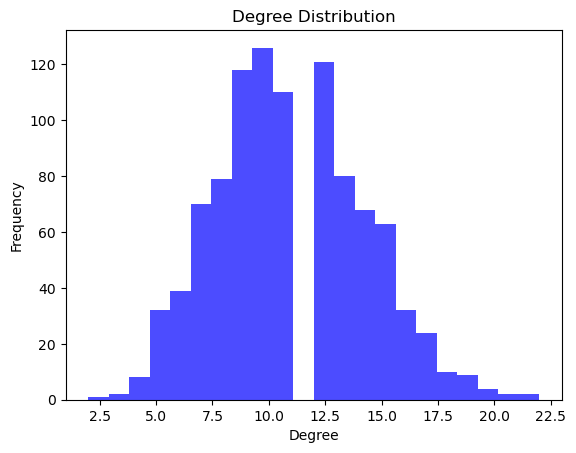

In [5]:
# plot degree distribution
degree_sequence = sorted([d for n, d in G_test.degree()], reverse=True) 
plt.hist(degree_sequence, bins=22, color='blue', alpha=0.7)
plt.title("Degree Distribution")    
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

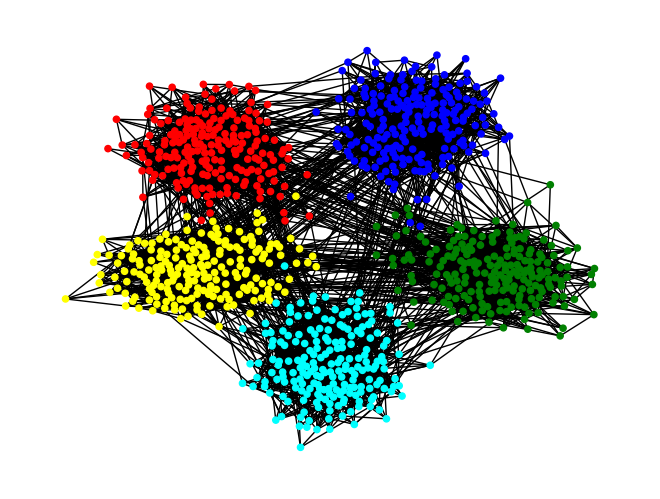

In [6]:
# visualise G and color nodes according to their block
# this is a super dumb way of doing it but oh well
color_map = []
for node in G_test.nodes():
    if node < 200:
        color_map.append('red')
    elif node < 400:
        color_map.append('blue')
    elif node < 600:
        color_map.append('green')
    elif node < 800:
        color_map.append('yellow')
    else:
        color_map.append('cyan')    
nx.draw(G_test, node_color=color_map, with_labels=False, node_size=20)
plt.show()

### BHD
- Start self-avoiding random walk at random node $v_0$. After each step (past the 2nd one in the RW) do procedure
- $v_t$: RW node at step $t$, $f_t$: set of neighbours of $v_t$, $F_{t-1}= f_0 ∪ f_1 ∪ f_2 ∪ \dots  ∪ f_{t-1}$: Union of friendship circles/neighbours of all previously visited nodes
    - If every other node in $f_t$ already belongs to $F_{t-1}$ or at least has a link to it: $v_t$ not a target -> RW moves on
    - Else, at least one node in $f_t$ not connected to $F_{t-1}$: $v_t$ is immunization target; also random node of $f_t$ that cannot be linked back to $F_{t-1}$ is target -> new RW from random node
- Repeat until desired immunization ratio is achieved
- Terminate walks if no immunization targets found after 20 steps



Iteration 1: Starting node C1, neighbors {'C2', 'C4', 'C5', 'S', 'B', 'C3'}
Step 2: Moved to node C2, neighbors {'C4', 'C5', 'C3', 'C1'}
At node C3, neighbors {'C2', 'C4', 'C5', 'C1'}, friendship circle F {'C2', 'C4', 'C5', 'C1', 'S', 'B', 'C3'}
Candidate nodes for immunization: set()
Immunization targets (candidates with no links back to F): set()
No immunization targets found at node C3. Continuing walk.
At node C4, neighbors {'C2', 'C5', 'C3', 'C1'}, friendship circle F {'C2', 'C4', 'C5', 'C1', 'S', 'B', 'C3'}
Candidate nodes for immunization: set()
Immunization targets (candidates with no links back to F): set()
No immunization targets found at node C4. Continuing walk.
At node C5, neighbors {'C2', 'C4', 'C3', 'C1'}, friendship circle F {'C2', 'C4', 'C5', 'C1', 'S', 'B', 'C3'}
Candidate nodes for immunization: set()
Immunization targets (candidates with no links back to F): set()
No immunization targets found at node C5. Continuing walk.
No options to continue from node C5. Restar

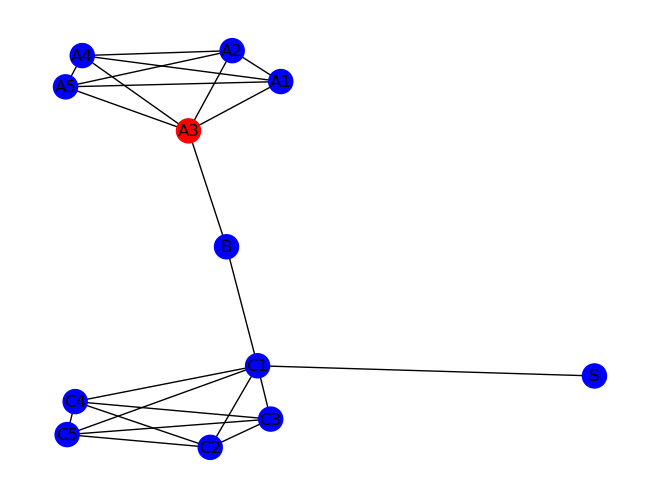

In [7]:
#let's make a test graph where we know for sure what should happen
G = nx.Graph()
# Community 1: dense clique of 5 nodes
community1 = ["A1", "A2", "A3", "A4", "A5"]
for i in range(len(community1)):
    for j in range(i+1, len(community1)):
        G.add_edge(community1[i], community1[j])
# Community 2: dense clique of 5 nodes
community2 = ["C1", "C2", "C3", "C4", "C5"]
for i in range(len(community2)):
    for j in range(i+1, len(community2)):
        G.add_edge(community2[i], community2[j])
# Bridge-hub node B: connects the two communities
# B's neighbourhood spans both cliques, so nodes on opposite sides
# have no links to each other - which means BHD should find it
G.add_edge("B", "A3")   # connects into community 1
G.add_edge("B", "C1")   # connects into community 2

# Satellite node S: connected only to C1, no link to B's friendship circle
# This makes S a valid immunization target when the walk is near B
G.add_edge("S", "C1")

# Run BHD — with 12 nodes, immunized_fraction=0.1 means we need ~1-2 nodes
immunized = imf.BHD(G, immunized_fraction=0.1, maxiter=20, verbose=True)
print("Immunized:", immunized)
# Expected: B should appear, and one of {A-nodes, C-nodes, or S} as the satellite target
color_map = []
for node in G.nodes():
    if node in immunized:
        color_map.append('red')
    else:
        color_map.append('blue')
nx.draw(G, node_color=color_map, with_labels=True, node_size=300)
plt.show()

Yay! Let's do another test on something marginally bigger:

Immunized nodes: {np.int64(64), np.int64(34), np.int64(37), np.int64(10), np.int64(77), np.int64(47), np.int64(17), np.int64(19), np.int64(28), np.int64(94)}


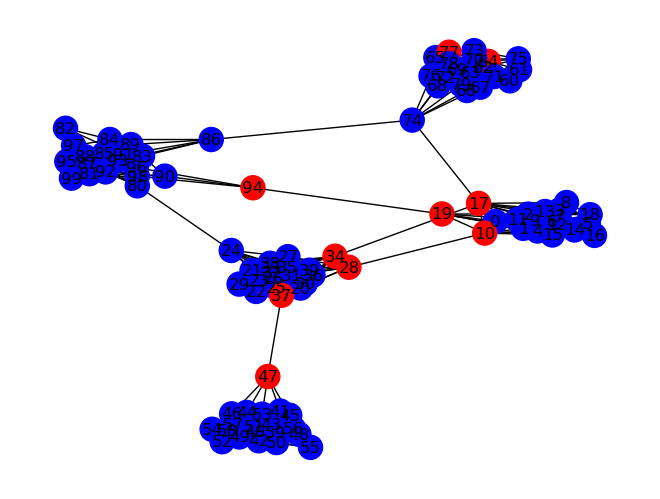

In [8]:
# make a tiny SBM graph and test BHD on it
n = 100
sizes = [20]* 5
p = np.outer(np.ones(len(sizes)), np.ones(len(sizes))) / (4*n)
p += np.diag([0.4]*len(sizes))
G = nx.stochastic_block_model(sizes, p)

immunized_nodes = imf.BHD(G, immunized_fraction=0.1) 
print("Immunized nodes:", immunized_nodes)

# visualise G and highlight immunized nodes
color_map = []
for node in G.nodes():
    if node in immunized_nodes:
        color_map.append('red')
    else:
        color_map.append('blue')
nx.draw(G, node_color=color_map, with_labels=True, node_size=300)
plt.show()

Now let's try with the Graph from the beginning, and run an SIR simulation as well (using the Epidemics on Networks library)!

In [9]:
tmax = 100 # maximum time for SIR simulation
beta = 0.12 #infection/transmission rate
gamma = 0.2 #recovery rate
#rho = 1/n      #random fraction initially infected, which doesn't work together with initial recovereds though???
immunized_fraction = 0.005
immunized_nodes = imf.BHD(G_test, immunized_fraction=immunized_fraction)

#run SIR simulation
results = EoN.fast_SIR(G_test, beta, gamma, tmax=tmax, initial_recovereds=immunized_nodes, return_full_data = True)

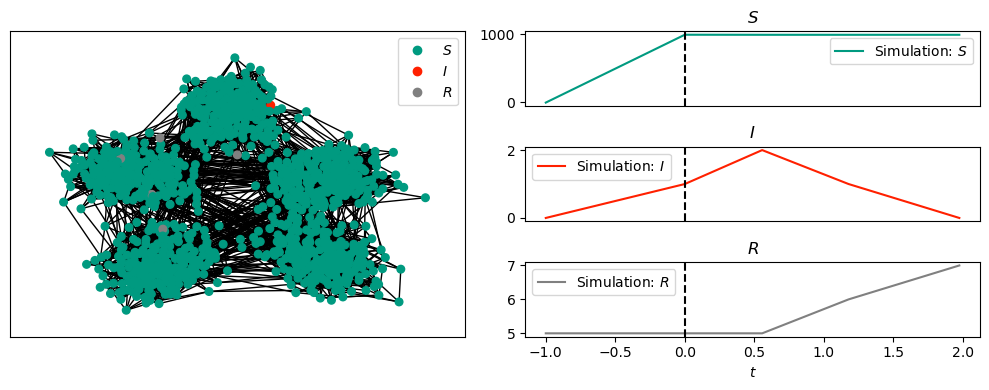

In [10]:
results.display(0, node_size=30) # this is very convenient, nice
plt.show()

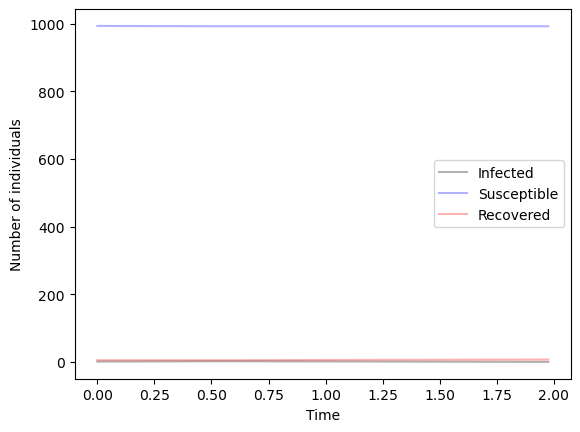

In [11]:
t, S, I, R = results.t(), results.S(), results.I(), results.R()
plt.plot(t[1:], I[1:], color = 'k', alpha=0.3, label='Infected')
plt.plot(t[1:], S[1:], color = 'b', alpha=0.3, label='Susceptible')
plt.plot(t[1:], R[1:], color = 'r', alpha=0.3, label='Recovered')
plt.xlabel('Time')
plt.ylabel('Number of individuals')
plt.legend()
plt.show()

### ACQ
Acquaintance immunization, as introduced by Cohen R, Havlin S, Ben-Avraham D (2003) Efficient immunization strategies for computer networks and populations. Phys Rev Lett 91(24):247901

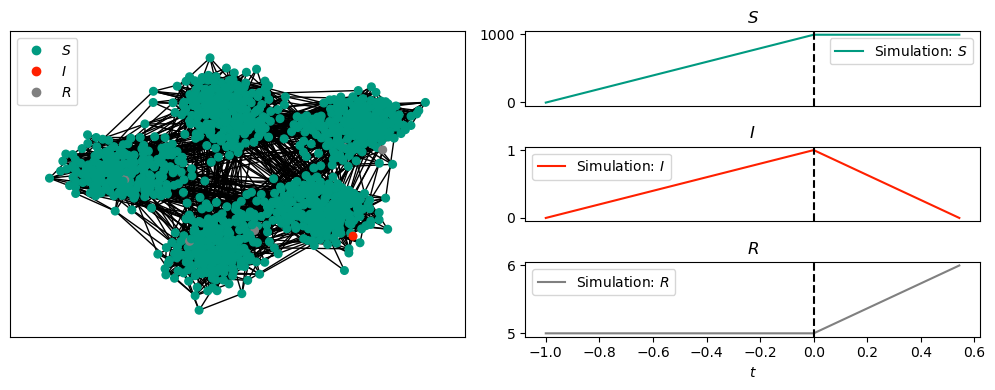

In [12]:
immunized_nodes = imf.ACQ(G_test, immunized_fraction=immunized_fraction, n_acq=2)

#run SIR simulation
results = EoN.fast_SIR(G_test, beta, gamma, tmax=tmax, initial_recovereds=immunized_nodes, return_full_data = True)
results.display(0, node_size=30) 
plt.show()

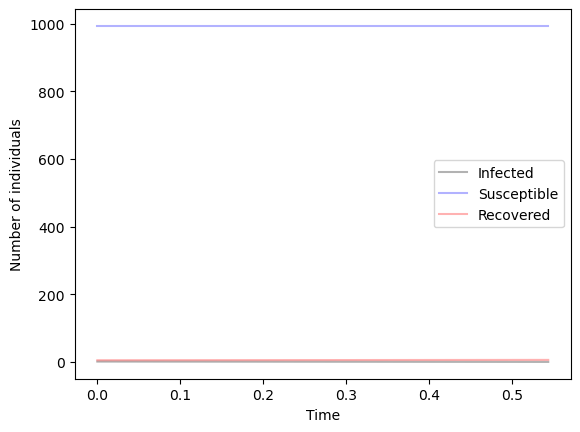

In [13]:
t, S, I, R = results.t(), results.S(), results.I(), results.R()
plt.plot(t[1:], I[1:], color = 'k', alpha=0.3, label='Infected')
plt.plot(t[1:], S[1:], color = 'b', alpha=0.3, label='Susceptible')
plt.plot(t[1:], R[1:], color = 'r', alpha=0.3, label='Recovered')
plt.xlabel('Time')
plt.ylabel('Number of individuals')
plt.legend()
plt.show()

### BNI-LI
see Zhang et al., 2026: "An immunization strategy for community networks based on local 
structural information"


Starting node 27, neighbors {32, 33, 34, 36, 39, 24, 25, 28, 29, 30, 31}
Step 2: Moved to node 36, neighbors {33, 35, 37, 23, 25, 27, 29, 30, 31}
Start successful. First RW nodes: {np.int64(27), np.int64(36)}, initial friendship circle: {23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39}. Starting main walk.
Node 33 at trial 0 has 2/2 backlinks to F. No candidate, continuing walk.
Node 38 at trial 1 added to target candidate pool with unconnected neighbour ratio(1/2).
Node 9 at trial 2 added to target candidate pool with unconnected neighbour ratio(0/3).
Node 10 at trial 3 added to target candidate pool with unconnected neighbour ratio(1/11).
Node 4 at trial 4 added to target candidate pool with unconnected neighbour ratio(0/8).
Immunized nodes: {np.int64(4), np.int64(38), np.int64(9), np.int64(10), np.int64(47)}


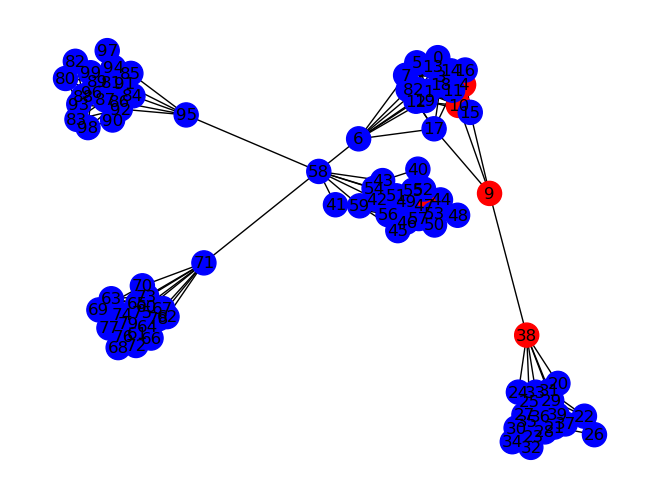

In [14]:
# make a tiny SBM graph and test BNI_LI on it
n = 100
sizes = [20]* 5
p = np.outer(np.ones(len(sizes)), np.ones(len(sizes))) / (4*n)
p += np.diag([0.4]*len(sizes))
G = nx.stochastic_block_model(sizes, p)

immunized_nodes = imf.BNI_LI(G, immunized_fraction=0.05, verbose=True) 
print("Immunized nodes:", immunized_nodes)

# visualise G and highlight immunized nodes
color_map = []
for node in G.nodes():
    if node in immunized_nodes:
        color_map.append('red')
    else:
        color_map.append('blue')
nx.draw(G, node_color=color_map, with_labels=True, node_size=300)
plt.show()

I am confused about handling dead ends as the random walk is supposed to be self-avoiding. What do we do if we can't continue? Where do we start? Do we restart from the same initialisation? Do we dump everything and restart the $R$ trials from scratch? For now, this is what I implemented.

### Building test networks
We need undirected, unweighted networks without self-loops and parallel edges

Salathé-Jones (CBF paper): 
- create 50 small-world communities of $N=40$ nodes via Watts-Strogatz, each node has exactly 8 
edges connecting to nodes of the same community
- add 2000 edges randomly between randomly chosen nodes between communities
- -> graph with 2000 nodes and 10000 (i.e. (2000+50 * 40 * (8/2))) undirected edges where one out of five edges falls between communities.
- increase community structure by rewiring between-community edges so that they become within-community edges: at each step
    - randomly choose a between-community edge,
    - randomly choose one of the two communities that the edge connects, 
    - pick a random node of the chosen community, 
    - rewire the edge by detaching it from the node of the community that was not chosen in step 2, and attaching it to the new node in the community that was chosen in step 3

Zhang et al. (BNI-LI paper): No tests on artificial networks! Which seems like a huge gap.

Gong et al. (BHD paper): same as CBF paper.


In [15]:
def generate_community_network(m = 50, n_sw=40, rewire_steps=0, verbose=False):
    n_tot = m*n_sw # total number of nodes in the graph
    k = int(0.2*n_sw) # number of inter-community edges per node
    sw_graphs = [nx.watts_strogatz_graph(n_sw, k=k, p=0.0) for _ in range(m)]    
    # create list of community labels for each node
    communities_partition = [{i*n_sw + j for j in range(n_sw)} for i in range(m)]  # sets of nodes
    G = nx.disjoint_union_all(sw_graphs)
    # add n_tot random inter-community edges
    added_edges = 0
    while added_edges < n_tot:
        c1, c2 = np.random.choice(m, size=2, replace=False) # get 2 random communities
        n1 = np.random.choice(n_sw) + c1*n_sw # get a random node from community 1
        n2 = np.random.choice(n_sw) + c2*n_sw # get a random node from community 2
        if not G.has_edge(n1, n2): # avoid multi-edges
            G.add_edge(n1, n2) # add an inter-community edge
            added_edges += 1
    # compute modularity
    if verbose:
        print("Modularity before rewiring:", nx.algorithms.community.quality.modularity(G, communities_partition))
        print("Average degree:", np.mean([d for n, d in G.degree()]))
    # rewire random between-community edges to within-community edges, to increase modularity
    betw_edges = set((u, v) for u, v in G.edges() if u // n_sw != v // n_sw)
    rewired = 0
    while rewired < rewire_steps:
        if not betw_edges:
            break
        # pick a random between-community edge
        edge = random.choice(list(betw_edges))    # pick a random endpoint to keep (u or v), and rewire the other one
        u, v = edge
        if np.random.rand() < 0.5:
            u, v = v, u # swap so that u is the one we keep
        # rewire v to a random node in the same community as u
        community = u // n_sw
        new_v = np.random.choice(n_sw) + community*n_sw
        # only add the new edge if it doesn't already exist, to avoid creating multi-edges
        # and also avoid self-loops
        if new_v != u and not G.has_edge(u, new_v):
            G.remove_edge(*edge)
            betw_edges.discard(edge)
            G.add_edge(u, new_v)
            rewired += 1

    modularity_final = nx.algorithms.community.quality.modularity(G, communities_partition)
    if verbose:
        print("Modularity after rewiring:", modularity_final)

    return G, communities_partition, modularity_final

In [16]:
n_sw = 40
m = 50
rewire_steps = 1000
G, communities_partition, modularity_final = generate_community_network(m=m, n_sw=n_sw, rewire_steps=rewire_steps, verbose=True)

Modularity before rewiring: 0.7799904100000004
Average degree: 10.0
Modularity after rewiring: 0.8799846800000001


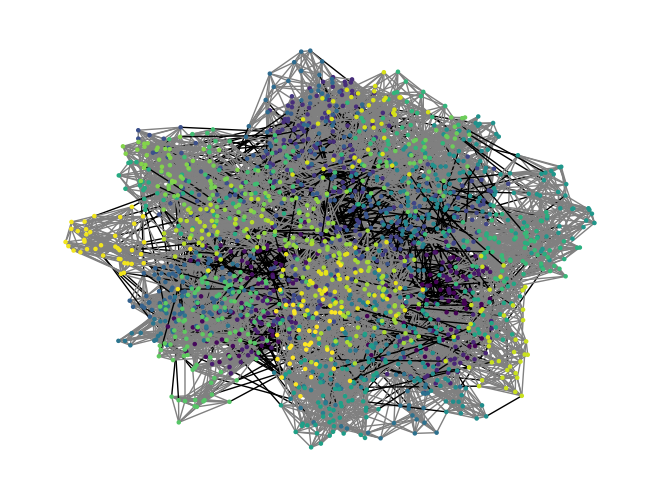

In [17]:

# plot G and color nodes according to their community_ground_truth
color_map = np.empty(G.number_of_nodes(), dtype=int)
for community_idx, community in enumerate(communities_partition):
    for node in community:
        color_map[node] = community_idx

# color edges based on whether they are intra- or inter-community
edge_colors = []
for u, v in G.edges():
    if u // n_sw == v // n_sw:
        edge_colors.append('gray')  # intra-community edge
    else:
        edge_colors.append('black')  # inter-community edge

nx.draw(G, node_color=color_map, with_labels=False, node_size=5, edge_color=edge_colors)
plt.show()

Let's check how the modularity behaves as we increase the number of rewiring steps:

In [18]:
# check modularity as function of rewiring steps
# repeat each point 10 times and average
# save standard deviation for error bars
rewire_steps_list = np.arange(0, 2001, 50)
modularity_values = []
for rewire_steps in rewire_steps_list:
    modularity_runs = []
    for _ in range(10):
        _, _, modularity = generate_community_network(m=50, n_sw=40, rewire_steps=rewire_steps, verbose=False)
        modularity_runs.append(modularity)
    modularity_values.append((np.mean(modularity_runs), np.std(modularity_runs)))


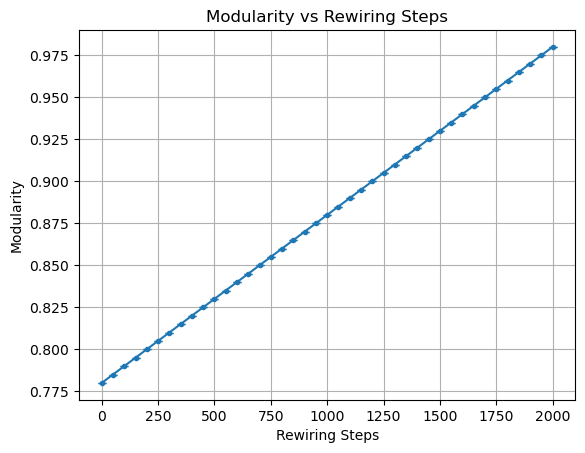

In [19]:
modularity_avg = [x[0] for x in modularity_values]
modularity_std = [x[1] for x in modularity_values]
plt.errorbar(rewire_steps_list, modularity_avg, yerr=modularity_std, marker='o', markersize=3, capsize=3)
plt.xlabel('Rewiring Steps')
plt.ylabel('Modularity')
plt.title('Modularity vs Rewiring Steps')
plt.grid()
plt.show()

In [21]:
# perform linear fit
m, b = np.polyfit(rewire_steps_list, modularity_avg, 1)
print(f"slope: {m}, intercept{b}")

slope: 9.999569588501718e-05, intercept0.7799898721881532


so +1 step -> +0.0001
+100 steps -> 0.01